In [1]:
from pathlib import Path
import os
from contextlib import contextmanager
from IPython import get_ipython

@contextmanager
def safe_chdir(target):
    prev_dir = Path.cwd()
    os.chdir(target)
    try:
        yield Path.cwd()
    finally:
        os.chdir(prev_dir)

file_dir = Path(get_ipython().run_line_magic('pwd', '')).resolve()
target_dir = file_dir / "../.."
with safe_chdir(target_dir):
    import src


In [2]:
import json
from src.utils.const import ARTIFACTS_PATH

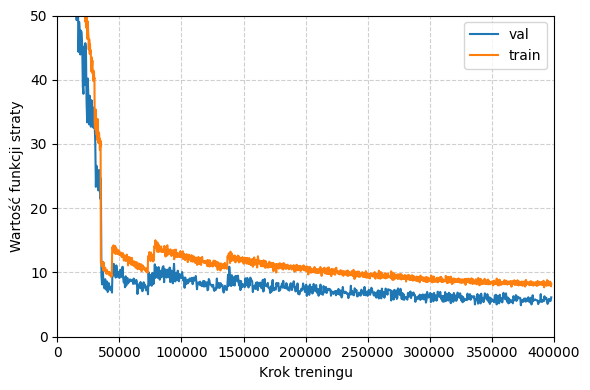

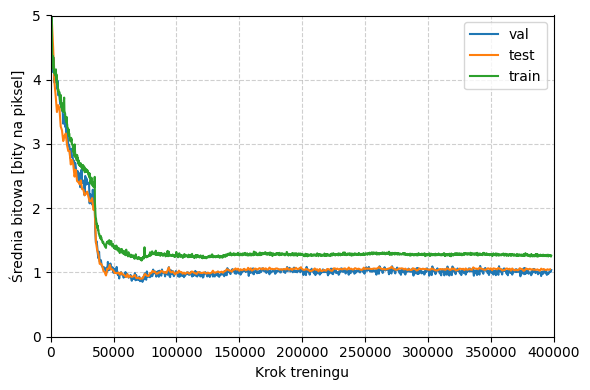

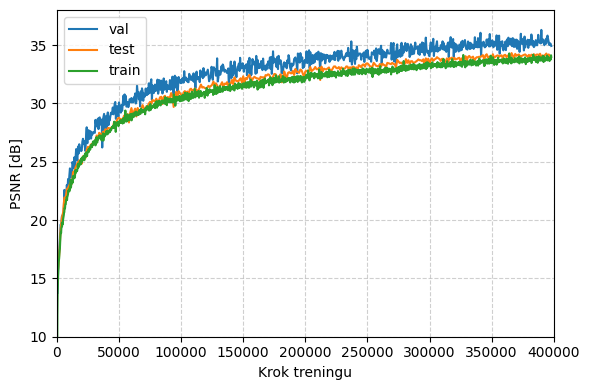

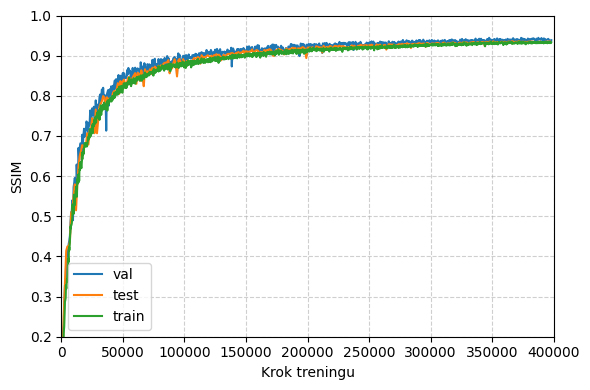

In [13]:
from datetime import datetime, timezone
from matplotlib import pyplot as plt

artifacts_dir = ARTIFACTS_PATH / (datetime.now(timezone.utc).strftime("%Y%m%dT%H%M") + "-14")
artifacts_dir.mkdir(parents=True, exist_ok=True)

with open(ARTIFACTS_PATH / 'Loss.json', 'r') as f:
    data = json.load(f)

px = 1/plt.rcParams['figure.dpi']

plt.figure(figsize=(600*px, 400*px))
plt.style.use('default')

for entry in data:
    name = entry['name']
    x = entry['x']
    y = entry['y']

    plt.plot(x, y, label=name)

plt.xlabel('Krok treningu')
plt.ylabel('Wartość funkcji straty')
plt.ylim(0, 50)
plt.xlim(0, 400000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(artifacts_dir / "loss.png")

with open(ARTIFACTS_PATH / 'bpp.json', 'r') as f:
    data = json.load(f)

px = 1/plt.rcParams['figure.dpi']

plt.figure(figsize=(600*px, 400*px))
plt.style.use('default')

for entry in data:
    name = entry['name']
    x = entry['x']
    y = entry['y']

    plt.plot(x, y, label=name)

plt.xlabel('Krok treningu')
plt.ylabel('Średnia bitowa [bity na piksel]')
plt.ylim(0, 5)
plt.xlim(0, 400000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(artifacts_dir / "bpp.png")

with open(ARTIFACTS_PATH / 'PSNR.json', 'r') as f:
    data = json.load(f)

plt.figure(figsize=(600*px, 400*px))
plt.style.use('default')

for entry in data:
    name = entry['name']
    x = entry['x']
    y = entry['y']

    plt.plot(x, y, label=name)

plt.xlabel('Krok treningu')
plt.ylabel('PSNR [dB]')
plt.ylim(10, 38)
plt.xlim(0, 400000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(artifacts_dir / "psnr.png")

with open(ARTIFACTS_PATH / 'SSIM.json', 'r') as f:
    data = json.load(f)

plt.figure(figsize=(600*px, 400*px))
plt.style.use('default')

for entry in data:
    name = entry['name']
    x = entry['x']
    y = entry['y']

    plt.plot(x, y, label=name)

plt.xlabel('Krok treningu')
plt.ylabel('SSIM')
plt.ylim(0.2, 1)
plt.xlim(0, 400000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(artifacts_dir / "ssim.png")